# Classification des œuvres de Zola et d'autres naturalistes

## Expérience avec retrait d'une liste de noms propres

## 1. Importation des bibliothèques

In [1]:
# Fichiers et données
import os
import glob
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Représentation textuelle
from sklearn.feature_extraction.text import TfidfVectorizer

# Modèles
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Pipelines et validation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Toutes les bibliothèques sont chargées.")

Toutes les bibliothèques sont chargées.


## 2. Normalisation des apostrophes

Les textes ayant été préalablement nettoyés, certaines apostrophes ont
disparu. Cette étape restaure les contractions les plus fréquentes à partir
d'un dictionnaire de correspondances.

N.b: Les formes `dune` et `lune` sont respectivement interprétées comme `d'une`
et `l'une`. Ce choix repose sur l'hypothèse que les occurrences des noms
communs *dune* et *lune* sont minoritaires dans le corpus étudié.

In [ ]:
REMPLACEMENTS_APOSTROPHES = {
    # ========================================================
    # Locutions longues : à traiter avant les formes courtes
    # ========================================================
    "lorsquil": "lorsqu'il",
    "lorsquils": "lorsqu'ils",
    "lorsquon": "lorsqu'on",
    "lorsquune": "lorsqu'une",
    "lorsquun": "lorsqu'un",
    "lorsquelle": "lorsqu'elle",
    "lorsquelles": "lorsqu'elles",

    "puisquil": "puisqu'il",
    "puisquils": "puisqu'ils",
    "puisquon": "puisqu'on",
    "puisquune": "puisqu'une",
    "puisquun": "puisqu'un",
    "puisquelle": "puisqu'elle",
    "puisquelles": "puisqu'elles",

    "quoiquil": "quoiqu'il",
    "quoiquils": "quoiqu'ils",
    "quoiquon": "quoiqu'on",
    "quoiquelle": "quoiqu'elle",

    "jusquil": "jusqu'il",
    "jusquils": "jusqu'ils",
    "jusquon": "jusqu'on",
    "jusquune": "jusqu'une",
    "jusquun": "jusqu'un",
    "jusquelle": "jusqu'elle",
    "jusquelles": "jusqu'elles",
    "jusquà": "jusqu'à",
    "jusquau": "jusqu'au",
    "jusquaux": "jusqu'aux",

    # ========================================================
    # Contractions avec c'
    # ========================================================
    "cest": "c'est",
    "cétait": "c'était",
    "cétaient": "c'étaient",
    "cétant": "c'étant",
    "cen": "c'en",

    # ========================================================
    # Contractions avec s'
    # ========================================================
    "sest": "s'est",
    "sétait": "s'était",
    "sétaient": "s'étaient",
    "sétant": "s'étant",
    "sen": "s'en",
    "sy": "s'y",
    "sil": "s'il",
    "sils": "s'ils",

    # ========================================================
    # Contractions avec n'
    # ========================================================
    "nest": "n'est",
    "nétait": "n'était",
    "nétaient": "n'étaient",
    "navait": "n'avait",
    "navaient": "n'avaient",
    "naurait": "n'aurait",
    "nauraient": "n'auraient",
    "naura": "n'aura",
    "nauront": "n'auront",
    "na": "n'a",
    "nont": "n'ont",
    "nen": "n'en",
    "ny": "n'y",
    "navoir": "n'avoir",
    "nêtre": "n'être",
    "nai": "n'ai",
    "navez": "n'avez",

    # ========================================================
    # Contractions avec j'
    # ========================================================
    "jai": "j'ai",
    "javais": "j'avais",
    "jétais": "j'étais",
    "jaurais": "j'aurais",
    "jaurai": "j'aurai",
    "jaime": "j'aime",
    "jallais": "j'allais",
    "jignore": "j'ignore",
    "jentends": "j'entends",
    "jen": "j'en",
    "jy": "j'y",

    # ========================================================
    # Contractions avec qu'
    # ========================================================
    "quest": "qu'est",
    "quil": "qu'il",
    "quils": "qu'ils",
    "quon": "qu'on",
    "quun": "qu'un",
    "quune": "qu'une",
    "quà": "qu'à",
    "quen": "qu'en",


    # ========================================================
    # Contractions avec d'
    # ========================================================
    "dune": "d'une", #je prend le parti de mettre d'apostrophe mais il y a un risque de confusion avec "d'une" (de une) et "dune" (la dune) 
    "dun": "d'un",
    "delle": "d'elle",
    "delles": "d'elles",
    "dêtre": "d'être",
    "davoir": "d'avoir",
    "dabord": "d'abord",
    "dailleurs": "d'ailleurs",
    "daprès": "d'après",
    "daccord": "d'accord",
    "davance": "d'avance",
    "doù": "d'où",
    "dautres": "d'autres",
    "damour": "d'amour",
    "dargent": "d'argent",
    "despoir": "d'espoir",
    "den": "d'en",
    "desprit": "d'esprit",
    'deau': "d'eau",

    # ========================================================
    # Contractions avec l'
    # ========================================================
    "labbé": "l'abbé",
    "lair": "l'air",
    "lâme": "l'âme",
    "lami": "l'ami",
    "lamie": "l'amie",
    "lamour": "l'amour",
    "largent": "l'argent",
    "lautre": "l'autre",
    "lun": "l'un",
    "lune": "l'une",
    "lheure": "l'heure",
    "lhomme": "l'homme",
    "lhonneur": "l'honneur",
    "lhistoire": "l'histoire",
    "lhôtel": "l'hôtel",
    "léglise": "l'église",
    "lépoque": "l'époque",
    "lenfant": "l'enfant",
    "lendroit": "l'endroit",
    "lentrée": "l'entrée",
    "lintérieur": "l'intérieur",
    "lidée": "l'idée",
    "lombre": "l'ombre",
    "loeil": "l'œil",
    "lœil": "l'œil",
    "lon": "l'on",
    "lai": "l'ai",
    "lavait": "l'avait",
    "leau": "l'eau",
    "lesprit": "l'esprit",
    "lescalier": "l'escalier",
    "létudiant": "l'étudiant",
    'lavenir': "l'avenir",
    "laffaire": "l'affaire",
    "loreille": "l'oreille",
    "lavocat": "l'avocat",

    # ========================================================
    # Locutions courantes
    # ========================================================
    "aujourdhui": "aujourd'hui",
    "presquun": "presqu'un",
    "presquune": "presqu'une",
    "quelquun": "quelqu'un",
    "quelquune": "quelqu'une",

    # ========================================================
    # Verbes pronominaux fréquemment rencontrés
    # ========================================================
    "sécria": "s'écria",
    "sécriait": "s'écriait",
    "sécrièrent": "s'écrièrent",
    "saperçut": "s'aperçut",
    "sapercevait": "s'apercevait",
    "sapprocha": "s'approcha",
    "sapprochait": "s'approchait",
    "sarrêta": "s'arrêta",
    "sarrêtait": "s'arrêtait",
    "sassit": "s'assit",
    "sétendit": "s'étendit",
    "séloigna": "s'éloigna",
    "séloignait": "s'éloignait",
    
    # m'
    "men": "m'en",
    "mavez": "m'avez",
    "mavait": "m'avait",
    
    "daller": "d'aller",
    "lappartement": "l'appartement",
    "lhuile": "l'huile",
    "mest": "m'est",
    "dhonneur": "d'honneur",
    "dici": "d'ici",
    "neût": "n'eût",
    "sécrie": "s'écrie",
    "ce quelle": "ce qu'elle",
    "ten": "t'en",
    "dhenriette": "d'Henriette",
    "lart": "l'art",
    "quau": "qu'au",
    "quaux": "qu'aux",
    "dautre": "d'autre",
    "dautres": "d'autres",
    "navais": "n'avais",
    "navions": "n'avions",
    "sagit": "s'agit",
    #=============================
    #Artecfact OCR
    #=============================
    "jé":"je",
    "dé":"de", 
    "lé": "le", 
    "mé":"me", 
    "cé":"ce", 
    "qué":"que",
    "dor": "d'or", 
    "my": "m'y", 
    "ten": "t'en",
    "né": "ne",
}

def adapter_casse(forme_originale, remplacement):
    """Conserve approximativement la casse du mot d'origine."""

    if forme_originale.isupper():
        return remplacement.upper()

    if forme_originale[0].isupper():
        return remplacement[0].upper() + remplacement[1:]

    return remplacement


def restaurer_apostrophes(texte):
    """Restaure certaines apostrophes supprimées avec une forte confiance."""

    remplacements_tries = sorted(
        REMPLACEMENTS_APOSTROPHES.items(),
        key=lambda element: len(element[0]),
        reverse=True
    )

    for forme_nettoyee, forme_corrigee in remplacements_tries:
        motif = rf"\b{re.escape(forme_nettoyee)}\b"

        texte = re.sub(
            motif,
            lambda correspondance: adapter_casse(
                correspondance.group(0),
                forme_corrigee
            ),
            texte,
            flags=re.IGNORECASE
        )

    return texte

## 3. Segmentation des fichiers en blocs de 3 lignes

In [3]:
def segmenter_en_paquets(texte, taille_paquet=3):
    lignes = texte.splitlines()
    lignes = [ligne.strip() for ligne in lignes if ligne.strip()]

    paquets = []

    for i in range(0, len(lignes), taille_paquet):
        paquet = " ".join(lignes[i:i + taille_paquet])
        if paquet:
            paquets.append(paquet)
    return paquets


def determiner_label(nom_fichier):
    if nom_fichier.startswith("Émile_Zola"):
        return "Zola"
    return "naturaliste"


def construire_dataframe(liste_fichiers):
    donnees = []

    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        label = determiner_label(nom_fichier)

        with open(chemin_fichier, "r", encoding="utf-8") as fichier:
            texte = fichier.read()
        # Restauration appliquée aux deux corpus
        texte = restaurer_apostrophes(texte)
        blocs = segmenter_en_paquets(
            texte)
        for bloc in blocs:
            donnees.append({
                "texte": bloc,
                "label": label,
                "source": nom_fichier
            })
    return pd.DataFrame(donnees)

chemin_dossier = "Z_vs_N"

liste_fichiers = sorted(glob.glob(os.path.join(chemin_dossier, "*.txt")))

print(f"Nombre de fichiers trouvés : {len(liste_fichiers)}")

from sklearn.model_selection import StratifiedGroupKFold

df_complet = construire_dataframe(liste_fichiers)

sgkf = StratifiedGroupKFold(
    n_splits=5,       # environ 20 % dans le test
    shuffle=True,
    random_state=42
)

train_indices, test_indices = next(
    sgkf.split(
        X=df_complet["texte"],
        y=df_complet["label"],
        groups=df_complet["source"]
    )
)

df_train = df_complet.iloc[train_indices].reset_index(drop=True)
df_test = df_complet.iloc[test_indices].reset_index(drop=True) 

print("\nTRAIN")
print(df_train["label"].value_counts())
print("Nombre d'œuvres :", df_train["source"].nunique())

print("\nTEST")
print(df_test["label"].value_counts())
print("Nombre d'œuvres :", df_test["source"].nunique())

Nombre de fichiers trouvés : 59

TRAIN
label
Zola           36860
naturaliste    30173
Name: count, dtype: int64
Nombre d'œuvres : 47

TEST
label
Zola           9478
naturaliste    7523
Name: count, dtype: int64
Nombre d'œuvres : 12


## 4. Vérification de la composition des corpus

Cette section vérifie le nombre de segments, les œuvres présentes et leur
répartition entre les classes dans les corpus d'entraînement et de test.

In [4]:
print("Textes dans le train")
print(len(df_train))

sources_par_label = (df_train.groupby("label")["source"].apply(lambda x: x.dropna().unique().tolist()))
print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")
        
print("\n\n\nTextes dans le test")
print(len(df_test))
        
sources_par_label = (df_test.groupby("label")["source"].apply(lambda x: x.dropna().unique().tolist()))
print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

Textes dans le train
67033
------------------------------
Sources par label :

Zola :
  - Émile_Zola_Au_Bonheur_des_dames.txt
  - Émile_Zola_Germinal.txt
  - Émile_Zola_L_Argent.txt
  - Émile_Zola_L_Œuvre.txt
  - Émile_Zola_La_Curée.txt
  - Émile_Zola_La_Débâcle.txt
  - Émile_Zola_La_Faute_de_l_abbé_Mouret.txt
  - Émile_Zola_La_Fortune_des_Rougon.txt
  - Émile_Zola_La_Joie_de_vivre.txt
  - Émile_Zola_La_Terre.txt
  - Émile_Zola_Le_Docteur_Pascal.txt
  - Émile_Zola_Le_Rêve.txt
  - Émile_Zola_Le_Ventre_de_Paris.txt
  - Émile_Zola_Nana.txt
  - Émile_Zola_Pot_Bouille.txt
  - Émile_Zola_Son_Excellence_Eugène_Rougon.txt

naturaliste :
  - Alphonse_Daudet_La_Belle_Nivernaise.txt
  - Alphonse_Daudet_Le_Nabab.txt
  - Alphonse_Daudet_Le_Soutien_de_famille.txt
  - Alphonse_Daudet_Les_Rois_en_exil.txt
  - Champfleury_La_Petite_Rose.txt
  - Champfleury_Les_Amis_de_la_nature.txt
  - Champfleury_Les_Confessions_de_Sylvius.txt
  - Edmond_de_Goncourt_La_Faustin.txt
  - Edmond_de_Goncourt_Les_Frères_Zem

In [5]:
# ============================================================
# Construction de la liste des noms propres à retirer
# ============================================================

chemin_json = Path("patronime.json")
with chemin_json.open("r", encoding="utf-8") as fichier:
    personnages_zola = json.load(fichier)

stop_words_noms_propres = [
    # Déjà présents
    "buteau", "florent",  "faujas", "pauline",  "coupeau", "plassans", "nana", "chanteau", "josserand",
    "miette", "lazare", "frédéric", "emma", "arnoux","faustin", "germinie", "duroy", "birotteau",

    # Noms associés aux textes de Zola
    "berthe","martine", "véronique", "kahn",

    # Noms associés aux autres naturalistes
    "joachim", "mathéus", "louveau", "durtal", "émile", "forestier",
    "allart", "césar", "julien", "quesnoy", "francis", "dambreuse", "walter","deslauriers",
    "christiane", "gontran", "rosanette", "andermatt", "lorilleux", "maheude", "trublot",
    "chaval", "delaherche", "fagerolles", "campardon", "delestang", "gavard",
    "poizat", "rastoil", "goujet", "condamin", "aurélie", "hubertine", "jeanlin",
    "bourdoncle", "gilquin", "mahoudeau", "robineau","jory", "hutin", "saturnin", "bouchard", "lerat",
    "chaudoreille", "urbain", "popinot", "corbie", "touquet","gorenflot", "sylvius","charlotte", "stauernaghel", "tillet",
    "julia", "césarine", "max","oriol","rosalie","hamilcar", "colombine", "roy",
      "montsou",

    "rasseneur", "bécu", "zacharie", "hubert", "trouche", "saget", "rognes",
    "hourdequin", "chouteau", "charbonnel", "granoux", "gundermann", "gueulin",
    "marjolin", "boves", "loubet", "ramond","voreux", "gagnière", "marsy", "macqueron",

    # Autres œuvres
    "bird", "roguin", "mâtho",
    "esseintes", "jenkins","spendius","homais", "eudeline", "baudouin", "paule", "popeland",
    "ragon", "niflart", "perrin", "izoard", "brétigny",
    "rodolphe", "marcel", "anselme", "rouquette", "lapoulle", "dubuche", "gourd", "sarriette",
    "rochas", "mazaud", "bonneville", "vabre", "favier", "bazeilles",
    "paloque", "lengaigne", "béjuin","dide", "meuse", "henriette", "claparon", "jansoulet", "bigle",
    "tournelles", "lestang", "guay", "lefèvre", "carthage",  "sénécal",
    "hussonnet", "germain", "félix", "juzeur", "delangre", "lecœur", "bongrand", "nénesse", "bonnemort",
    "bourrette", "vallagnosc", "jantrou", "deloche", "roudier", "neuville", "villebelle",
    "dina", "christian", "marelle",
    
]
    
stop_words_noms_propres_set = set()

for personnage in personnages_zola:
    for champ in ("prenom", "nom"):
        valeur = personnage.get(champ, "")

        mots = re.findall(r"\b[\wÀ-ÿ'-]+\b",valeur.lower())

        stop_words_noms_propres_set.update(mots)

stop_words_noms_propres_set.update(mot.lower()for mot in stop_words_noms_propres)

stop_words = sorted(stop_words_noms_propres_set)

print(
    "Nombre total de noms propres retirés :",
    len(stop_words)
)

# Séparation des textes et des labels
X_train = df_train["texte"].fillna("")
y_train = df_train["label"]

X_test = df_test["texte"].fillna("")
y_test = df_test["label"]


# ====================================================================
# # Construction de la représentation TF-IDF commune aux trois modèles
# ====================================================================


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words=stop_words
)

# Le vocabulaire et les poids IDF sont appris uniquement sur le train
vectorizer.fit(X_train)

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du test  :", X_test_tfidf.shape)

Nombre total de noms propres retirés : 493
Dimensions du train : (67033, 10000)
Dimensions du test  : (17001, 10000)


## 7. Validation croisée groupée et sélection du modèle

Les trois modèles sont évalués sur les mêmes plis de
`StratifiedGroupKFold`. Les segments d'une même œuvre restent dans un seul
groupe afin d'éviter qu'une œuvre apparaisse simultanément dans
l'entraînement et la validation.

Le critère principal de sélection est le F1 macro moyen.

In [6]:
X = df_train["texte"].fillna("").to_numpy()
Y = df_train["label"].to_numpy()
groups = df_train["source"].to_numpy()

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Les plis sont calculés une seule fois pour garantir la même
# séparation pour tous les modèles.
plis = list(cv.split(X, Y, groups=groups))


modeles = {
    "Naive Bayes": Pipeline([
        ("tfidf", vectorizer),
        ("clf", MultinomialNB(alpha=1.0))
    ]),

    "Régression logistique": Pipeline([
        ("tfidf", vectorizer),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),

    "LDA": Pipeline([
        ("tfidf", vectorizer),
        ("svd", TruncatedSVD(
            n_components=100,
            random_state=42
        )),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(
            solver="svd"
        ))
    ])
}

resultats = []

for nom, modele in modeles.items():
    scores = cross_validate(
        modele,
        X,
        Y,
        cv=plis,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        return_train_score=True,
        n_jobs=1  # mettre -1 uniquement si la mémoire disponible le permet
    )

    resultats.append({
        "modèle": nom,
        "F1 macro moyen": scores["test_f1_macro"].mean(),
        "écart-type F1": scores["test_f1_macro"].std(),
        "accuracy moyenne": scores["test_accuracy"].mean(),
        "F1 entraînement": scores["train_f1_macro"].mean()
    })

comparaison_cv = (
    pd.DataFrame(resultats)
    .sort_values("F1 macro moyen", ascending=False)
    .reset_index(drop=True)
)

for numero, (indices_train, indices_validation) in enumerate(plis, start=1):
    sources_train = set(groups[indices_train])
    sources_validation = set(groups[indices_validation])

    intersection = sources_train & sources_validation

    print(
        f"Pli {numero} : "
        f"{len(sources_train)} œuvres train, "
        f"{len(sources_validation)} œuvres validation, "
        f"intersection = {len(intersection)}"
    )

    assert len(intersection) == 0
    
display(comparaison_cv)

Pli 1 : 38 œuvres train, 9 œuvres validation, intersection = 0
Pli 2 : 38 œuvres train, 9 œuvres validation, intersection = 0
Pli 3 : 37 œuvres train, 10 œuvres validation, intersection = 0
Pli 4 : 38 œuvres train, 9 œuvres validation, intersection = 0
Pli 5 : 37 œuvres train, 10 œuvres validation, intersection = 0


,modèle,F1 macro moyen,écart-type F1,accuracy moyenne,F1 entraînement
0,Régression logistique,0.821869,0.018578,0.824341,0.917407
1,Naive Bayes,0.761814,0.035404,0.767621,0.849540
2,LDA,0.732075,0.025147,0.738955,0.769780


## 8. Entraînement final et évaluation sur le corpus de test

### 8.1 Naive Bayes multinomial

              precision    recall  f1-score   support

        Zola       0.76      0.83      0.80      9478
 naturaliste       0.76      0.68      0.72      7523

    accuracy                           0.76     17001
   macro avg       0.76      0.75      0.76     17001
weighted avg       0.76      0.76      0.76     17001

[[7860 1618]
 [2422 5101]]


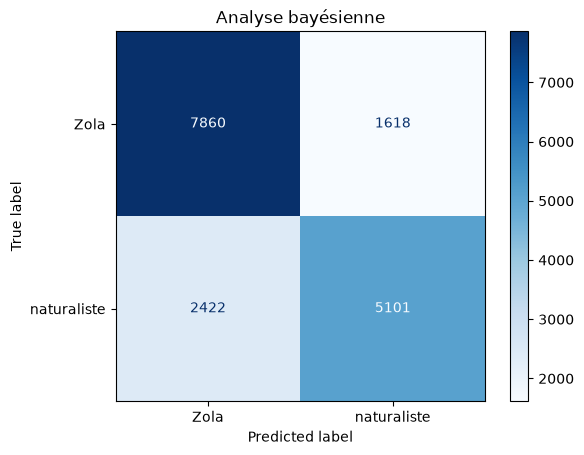

In [7]:
modele_bayes = MultinomialNB(alpha=1)

modele_bayes.fit(X_train_tfidf, y_train)


predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

### 8.2 Régression logistique

=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.852     0.871     0.862      9478
 naturaliste      0.833     0.809     0.821      7523

    accuracy                          0.844     17001
   macro avg      0.843     0.840     0.841     17001
weighted avg      0.844     0.844     0.844     17001

Matrice de confusion :
[[8259 1219]
 [1435 6088]]


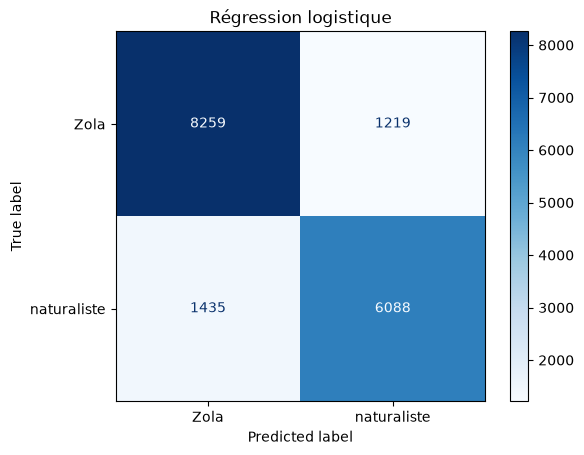

In [8]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()

### 8.3 Analyse discriminante linéaire après réduction SVD

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.

=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.148
              precision    recall  f1-score   support

        Zola      0.739     0.835     0.784      9478
 naturaliste      0.752     0.628     0.684      7523

    accuracy                          0.744     17001
   macro avg      0.745     0.732     0.734     17001
weighted avg      0.745     0.744     0.740     17001

Matrice de confusion :
[[7916 1562]
 [2797 4726]]


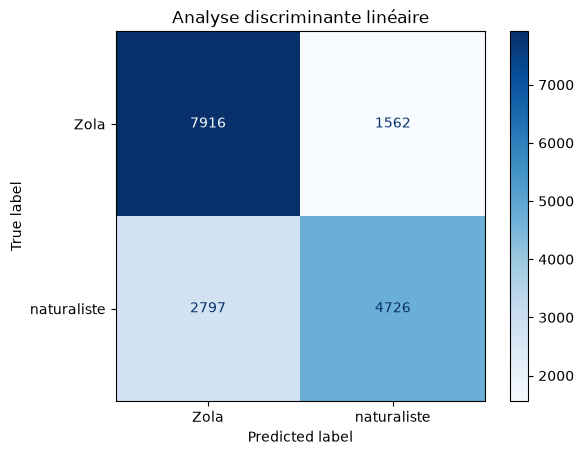

In [9]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


## 9. Comparaison des performances sur le corpus de test

Les résultats du corpus de test sont présentés après la sélection du modèle
par validation croisée. Ils constituent une évaluation complémentaire.

In [10]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

print("\nComparaison des modèles sur le jeu de test :")

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)


Comparaison des modèles sur le jeu de test :


,modèle,accuracy,f1_macro
0,Régression logistique,0.843892,0.841304
1,Analyse bayésienne,0.762367,0.755939
2,Analyse discriminante linéaire,0.743603,0.734247


## 10. Évaluation finale au niveau des œuvres

Les probabilités des segments appartenant à une même œuvre sont moyennées
afin d'obtenir une prédiction unique par œuvre.

In [11]:
probabilites = modele_logistique.predict_proba(
    X_test_tfidf
)

classe_zola = list(
    modele_logistique.classes_
).index("Zola")

evaluation_oeuvres = df_test[
    ["source", "label"]
].copy()

evaluation_oeuvres["probabilite_zola"] = (
    probabilites[:, classe_zola]
)

resultats_oeuvres = (
    evaluation_oeuvres
    .groupby("source")
    .agg(
        label_reel=("label", "first"),
        probabilite_zola=(
            "probabilite_zola",
            "mean"
        )
    )
    .reset_index()
)

resultats_oeuvres["prediction"] = np.where(
    resultats_oeuvres["probabilite_zola"] >= 0.5,
    "Zola",
    "naturaliste"
)

print(
    classification_report(
        resultats_oeuvres["label_reel"],
        resultats_oeuvres["prediction"],
        digits=3
    )
)

resultats_oeuvres

              precision    recall  f1-score   support

        Zola      1.000     1.000     1.000         4
 naturaliste      1.000     1.000     1.000         8

    accuracy                          1.000        12
   macro avg      1.000     1.000     1.000        12
weighted avg      1.000     1.000     1.000        12



,source,label_reel,probabilite_zola,prediction
0,Gustave_Flaubert_Madame_Bovary.txt,naturaliste,0.344035,naturaliste
1,Gustave_Flaubert_Salammbô.txt,naturaliste,0.403203,naturaliste
2,Guy_de_Maupassant_Mont_Oriol.txt,naturaliste,0.329018,naturaliste
3,J_H_Rosny_Nymphée.txt,naturaliste,0.292968,naturaliste
4,J_H_Rosny_aîné_Le_Cataclysme.txt,naturaliste,0.457069,naturaliste
5,Louis_Émile_Edmond_Duranty_Le_Malheur_d_Henrie...,naturaliste,0.268297,naturaliste
6,Paul_de_Kock_Georgette.txt,naturaliste,0.197533,naturaliste
7,Paul_de_Kock_La_Demoiselle_du_cinquième.txt,naturaliste,0.143435,naturaliste
8,Émile_Zola_L_Assommoir.txt,Zola,0.796910,Zola
9,Émile_Zola_La_Bête_humaine.txt,Zola,0.777541,Zola


## 11. Interprétation des modèles à partir du corpus d'entraînement

Cette section examine les paramètres appris par les modèles, sans tenir
compte de la fréquence des termes dans le corpus de test.

### 11.1 Termes caractéristiques selon Naive Bayes

In [12]:
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
albine                    3.927
fauchery                  3.702
muffat                    3.642
bordenave                 3.389
teuse                     3.388
prussiens                 3.352
vandeuvres                3.301
faloise                   3.210
steiner                   3.077
sedan                     3.067
fontan                    3.054
empereur                  3.048
labordette                3.040
les prussiens             3.017
coron                     3.002
insurgés                  2.847
paradou                   2.826
simonne                   2.677
archangias                2.671
frère archangias          2.671
comte muffat              2.583
jésus christ              2.556
belle normande            2.551
mineurs                   2.538
bourras                   2.513
nom dieu                  2.503
bonheur des               2.500
le colonel                2.490
cazenove           

### 11.2 Coefficients de la régression logistique

In [13]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
lorsque                        -6.9370
qu elle                        -6.4286
empereur                       -6.3496
ça                             -4.9702
albine                         -4.7865
ce fut                         -4.4559
hein                           -4.4090
fauchery                       -4.2819
lorsqu                         -4.2089
non non                        -4.0861
tout suite                     -3.9811
oncle                          -3.9620
finit                          -3.8946
justement                      -3.7850
dut                            -3.6799
au fond                        -3.6583
bordenave                      -3.6406
simplement                     -3.5965
muffat                         -3.5605
ce pas                         -3.5010
cria                           -3.4478
murmura                        -3.4293
armée                          -3.3462
venait                   

## 12. Analyse post-hoc du corpus de test

Cette section examine les termes effectivement présents dans le corpus de
test. Elle est uniquement interprétative et n'est pas utilisée pour
modifier le prétraitement, sélectionner le modèle ou régler ses
hyperparamètres.

### 12.1 Présence et poids TF-IDF des termes dans le test

In [14]:
# Utilisation du TF-IDF commun
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9864


### 12.2 Termes discriminants de Naive Bayes présents dans le test

In [15]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}")


Termes présents dans le test les plus caractéristiques de Zola :
prussiens                 score=3.352  extraits=1
empereur                  score=3.048  extraits=19
les prussiens             score=3.017  extraits=1
simonne                   score=2.677  extraits=2
jésus christ              score=2.556  extraits=2
nom dieu                  score=2.503  extraits=57
bonheur des               score=2.500  extraits=5
le colonel                score=2.490  extraits=6
dossiers                  score=2.461  extraits=6
foutre                    score=2.417  extraits=2
fit remarquer             score=2.407  extraits=14
entêtait                  score=2.385  extraits=17
charcuterie               score=2.364  extraits=4
le pis                    score=2.354  extraits=14
fosses                    score=2.333  extraits=7
clientes                  score=2.331  extraits=1
halles                    score=2.328  extraits=17
salon jaune               score=2.324  extraits=3
fosse                     sc

### 12.3 Contribution lexicale globale dans le corpus de test

L'indicateur ci-dessous combine le caractère discriminant appris par
Naive Bayes avec le poids TF-IDF total du terme dans le corpus de test.

Il s'agit d'un indicateur descriptif global. Il ne représente pas une
explication locale exacte de chaque prédiction.

In [16]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)


print(contributions_zola[["terme", "contribution_test"]])
print(contributions_naturalistes[["terme", "contribution_test"]])

           terme  contribution_test
2550        elle         408.545164
7043     qu elle         218.056801
9858       était         148.072033
589        avait         139.718044
9725          ça         126.024976
4730         les         112.210924
4071         ils         111.400467
2561  elle avait          87.017026
4990     lorsque          74.753793
7039          qu          73.011423
4983      lorsqu          72.521326
2655  elle était          68.123396
2630     elle se          64.356562
2602     elle ne          64.223489
9392      venait          62.884659
3163         eut          62.153470
8960        très          55.620077
5992          on          55.503728
462    au milieu          55.004376
1779        cria          54.520104
5636     murmura          53.726481
5439      milieu          52.987082
580      avaient          52.426798
5087          là          52.111704
3911    il avait          51.299460
511       aurait          50.615894
7466     restait          50

## 13. Conclusion

La régression logistique obtient les meilleures performances parmi les
trois modèles étudiés, avec un F1 macro moyen d'environ 0,81 en validation
croisée groupée. Elle atteint également un F1 macro d'environ 0,85 sur le
corpus de test.

La validation croisée est groupée par œuvre : les segments issus d'une même
œuvre ne peuvent pas apparaître simultanément dans l'entraînement et la
validation. Cette précaution limite le risque que le modèle reconnaisse une
œuvre déjà rencontrée.

Les neuf œuvres du corpus de test sont correctement classées après agrégation
des probabilités par œuvre. Ce résultat est encourageant, mais doit être
interprété avec prudence en raison du faible nombre d'œuvres évaluées.

L'écart entre le F1 d'entraînement et le F1 de validation indique néanmoins
un certain surapprentissage. Par ailleurs, malgré le retrait d'une liste
étendue de noms propres, le modèle continue d'exploiter des indices
lexicaux, thématiques, dialectaux et stylistiques propres aux œuvres.

Cette expérience sera comparée à une seconde configuration conservant les
noms propres, tous les autres paramètres du protocole restant identiques.

In [17]:
from sklearn.metrics import balanced_accuracy_score

print(
    "Balanced accuracy :",
    balanced_accuracy_score(
        y_test,
        predictions_logistiques
    )
)

Balanced accuracy : 0.8403189983859584


In [18]:
evaluation = df_test[["source", "label"]].copy()
evaluation["prediction"] = predictions_logistiques

performance_par_oeuvre = (
    evaluation
    .groupby("source")
    .apply(
        lambda groupe: pd.Series({
            "label_reel": groupe["label"].iloc[0],
            "n_segments": len(groupe),
            "accuracy_segments": (
                groupe["prediction"]
                == groupe["label"]
            ).mean(),
            "prediction_majoritaire": (
                groupe["prediction"]
                .value_counts()
                .idxmax()
            )
        }),
        include_groups=False
    )
    .reset_index()
)

print(performance_par_oeuvre)

print(
    "Accuracy moyenne par œuvre :",
    performance_par_oeuvre[
        "accuracy_segments"
    ].mean()
)

                                               source   label_reel  \
0                  Gustave_Flaubert_Madame_Bovary.txt  naturaliste   
1                       Gustave_Flaubert_Salammbô.txt  naturaliste   
2                    Guy_de_Maupassant_Mont_Oriol.txt  naturaliste   
3                               J_H_Rosny_Nymphée.txt  naturaliste   
4                    J_H_Rosny_aîné_Le_Cataclysme.txt  naturaliste   
5   Louis_Émile_Edmond_Duranty_Le_Malheur_d_Henrie...  naturaliste   
6                          Paul_de_Kock_Georgette.txt  naturaliste   
7         Paul_de_Kock_La_Demoiselle_du_cinquième.txt  naturaliste   
8                          Émile_Zola_L_Assommoir.txt         Zola   
9                      Émile_Zola_La_Bête_humaine.txt         Zola   
10             Émile_Zola_La_Conquête_de_Plassans.txt         Zola   
11                    Émile_Zola_Une_page_d_amour.txt         Zola   

    n_segments  accuracy_segments prediction_majoritaire  
0          939           0.738